# Домашнее задание по модулю «Улучшение качества модели»

**Этапы работы:**

1. Загрузите данные.
2. Подготовьте датасет к обучению моделей.
3. Разделите выборку на обучающее и тестовое подмножества.
4. Обучите классификатор KNN с параметрами по умолчанию и зафиксируйте качество модели.
5. Подберите оптимальное количество соседей и тип весов для алгоритма KNN. Сравните работу алгоритмов GridSearchCV и RandomizedSearchCV.
6. Сравните KNN с другой моделью.
7. Реализуйте Байесовскую оптимизацию.
8. Сделайте выводы о работе алгоритма.

### 1. Загрузка данных в рабочую среду.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import time

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
    )

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
    )
from xgboost import XGBClassifier

from hyperopt import hp, fmin, tpe, Trials, space_eval, STATUS_OK

In [ ]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


*Столбец HeartDisease (наличие болезни сердца) - целевая переменная*

In [ ]:
# заполненность столбцов и типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# описательная статистика числовых столбцов
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
df.nunique()

,0
Age,50
Sex,2
ChestPainType,4
RestingBP,67
Cholesterol,222
FastingBS,2
RestingECG,3
MaxHR,119
ExerciseAngina,2
Oldpeak,53


In [ ]:
# процентная доля пропусков в столбцах
print('Процентная доля пропусков в столбцах:')
df.isna().mean()*100

Процентная доля пропусков в столбцах:


,0
Age,0.0
Sex,0.0
ChestPainType,0.0
RestingBP,0.0
Cholesterol,0.0
FastingBS,0.0
RestingECG,0.0
MaxHR,0.0
ExerciseAngina,0.0
Oldpeak,0.0


In [ ]:
# проверка на дубликаты
print(f'Количество дубликатов: {df.duplicated().sum()}\n')
df[df.duplicated()]

Количество дубликатов: 0



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


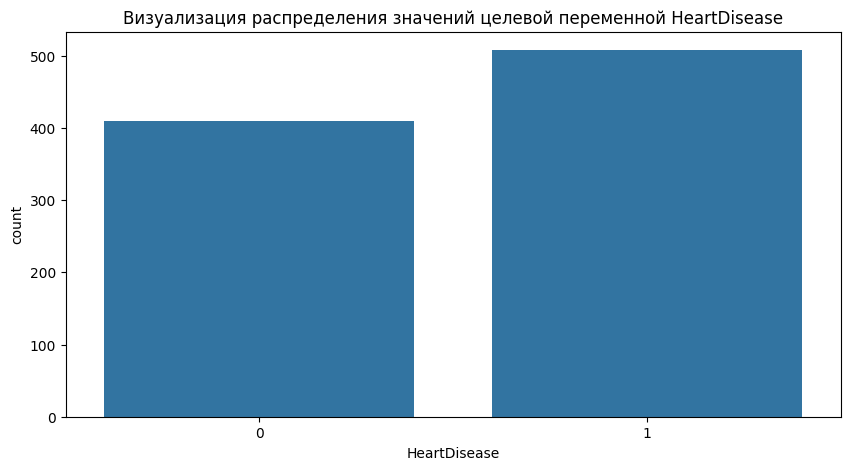

In [ ]:
# визуализация распределения целевой переменной HeartDisease
plt.figure(figsize=(10,5))

sns.countplot(x='HeartDisease', data=df)

plt.title('Визуализация распределения значений целевой переменной HeartDisease')
plt.show()

In [ ]:
# проверка баланса классов в целевой переменной
print(f'Количество значений {df['HeartDisease'].value_counts().to_string()}\n')
print(f'Доля класса 0: {df['HeartDisease'].value_counts(normalize=True)[0]:.2%}')
print(f'Доля класса 1: {df['HeartDisease'].value_counts(normalize=True)[1]:.2%}')

Количество значений HeartDisease
1    508
0    410

Доля класса 0: 44.66%
Доля класса 1: 55.34%


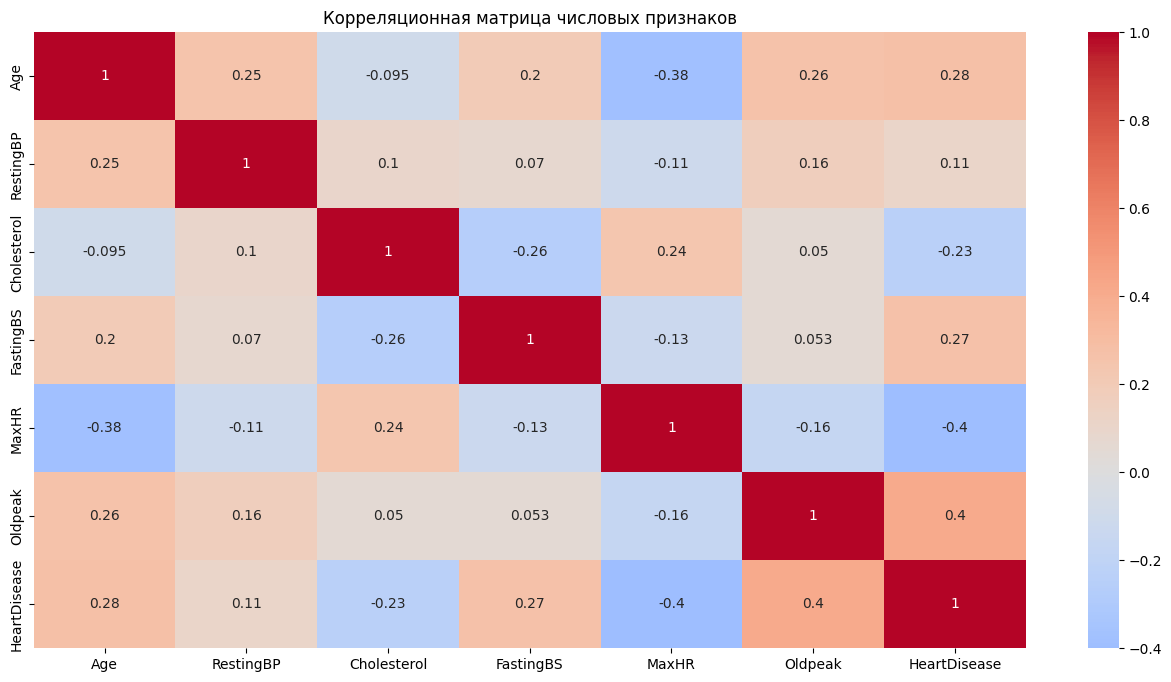

In [ ]:
# корреляционная матрица числовых признаков
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Корреляционная матрица числовых признаков')
plt.show()

В данных отсутствуют пропуски и дубликаты, целевая переменная распределена достаточно сбалансированно, хотя класс 1 немного преобладает. Сильных линейных зависимостей между числовыми признаками не наблюдается, что снижает риск мультиколлинеарности. Наиболее заметная связь с `HeartDisease` у `Oldpeak` (0.40) и `MaxHR` (-0.40), также умеренная связь наблюдается с `Age` и `FastingBS`. Это говорит о том, что отдельные признаки полезны для классификации, но задача требует использования их комбинации.


### 2. Подготовьте датасет к обучению моделей.

* Обработайте пропущенные значения и дубликаты.
* Категориальные переменные переведите в цифровые значения. Можно использовать `pd.get_dummies`, `preprocessing.LabelEncoder`. Старайтесь не использовать для этой задачи циклы.
* При необходимости выполните масштабирование признаков (например, `StandardScaler` для `KNN`) и объясните, как оно повлияло на качество модели.

*Пропусков и дубликатов нет, поэтому датасет в их обработке не нуждается*

*Масштабирование признаков будет выполнено после разделения на обучающую и тестовую выборки, в пайплайне KNN, во избежание утечки данных*

In [ ]:
# кодирование категориальных признаков
cat_cols = df.select_dtypes(include=['object']).columns.to_list()

df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1.5,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0.0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


### 3. Разделите выборки.

* Разделите данные на обучающую и тестовую выборки, используя train_test_split.
* 80% объектов используйте для обучения, 20% — для теста (test_size=0.2).
* При разделении используйте параметр stratify=y, чтобы сохранить пропорции классов.

In [ ]:
df_clean = df.copy()

In [ ]:
# определяем признаки и целевую переменную
X = df_clean.drop(columns=['HeartDisease'])
y = df_clean['HeartDisease']

In [ ]:
# разделение исходных данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
    )

### 4. Базовая модель KNN и кросс‑валидация.

* Обучите классификатор KNN с параметрами по умолчанию (`KNeighborsClassifier`).
* Реализуйте кросс‑валидацию с помощью функции `cross_val_score`.
* Зафиксируйте среднее качество, стандартное отклонение метрики и разброс значений по фолдам.
* Сделайте короткий вывод: насколько устойчива модель, есть ли признаки переобучения/недообучения.
Основная метрика — `accuracy`. По желанию можно дополнительно считать `F1` и/или `ROC-AUC`.

In [ ]:
# предобработка исходных числовых небинарных столбцов - масштабирование
numeric_columns = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
    ]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns)
    ],
    remainder='passthrough'
)

In [ ]:
# создание пайплайна предобработки и обучения модели KNN
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
    ])

In [ ]:
# обучение базовой модели модели
knn_pipeline.fit(X_train, y_train)

# предсказания
y_pred_knn = knn_pipeline.predict(X_test)
y_pred_proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]

# расчет и вывод метрик базовой модели
knn_baseline_metrics_df = pd.DataFrame({
    'Metrics': ['Accuracy', 'F1', 'ROC-AUC'],
    'KNN_baseline': [
        accuracy_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn),
        roc_auc_score(y_test, y_pred_proba_knn)
        ]
    })

print('Метрики базового KNN:\n')
knn_baseline_metrics_df.round(4)

Метрики базового KNN:



,Metrics,KNN_baseline
0,Accuracy,0.8913
1,F1,0.9020
2,ROC-AUC,0.9366


In [ ]:
# реализация cross_val_score для KNN
cv_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=5)

print(f'Оценки по фолдам: {cv_scores}')
print(f'Средняя точность: {cv_scores.mean():.3f}')
print(f'Стандартное отклонение: {cv_scores.std():.3f}')

Оценки по фолдам: [0.84353741 0.84353741 0.8707483  0.83673469 0.82191781]
Средняя точность: 0.843
Стандартное отклонение: 0.016


In [ ]:
# cводная таблица по Accuracy для KNN
knn_cv_summary_df = pd.DataFrame({
    'Metrics': ['Test Accuracy', 'CV Mean Accuracy', 'CV Std'],
    'KNN': [
        knn_baseline_metrics_df.loc[
            knn_baseline_metrics_df['Metrics'] == 'Accuracy',
            'KNN_baseline'
        ].iloc[0],
        cv_scores.mean(),
        cv_scores.std()
        ]
    })

print('Сводная таблица по Accuracy для KNN\n')
knn_cv_summary_df.round(4)

Сводная таблица по Accuracy для KNN



,Metrics,KNN
0,Test Accuracy,0.8913
1,CV Mean Accuracy,0.8433
2,CV Std,0.0158


Результаты 5-кратной кросс-валидации можно назвать стабильными: `Accuracy` по фолдам находится в диапазоне `0.822–0.871`, среднее значение составляет `CV Mean Accuracy = 0.843`, а стандартное отклонение — `CV Std = 0.016`. Это говорит о небольшой зависимости качества модели от конкретного разбиения обучающих данных.

На тестовой выборке `Test Accuracy = 0.8913`, то есть выше. Напрямую это не является признаком переобучения, потому что тестовое разбиение могло оказаться более благоприятным. Явных признаков недообучения тоже не наблюдается, поскольку модель показывает достаточно высокое качество.

### 5. Подбор гиперпараметров KNN: GridSearchCV и RandomizedSearchCV, их сравнение

Подберите оптимальное количество соседей и тип весов (“uniform” или “distance”) на основе `cross_val_score`.

* `GridSearchCV`.
    * Задайте сетку гиперпараметров.
    * Запустите `GridSearchCV` с нужной метрикой и числом фолдов.
    * Зафиксируйте лучший набор гиперпараметров, значение метрики и время работы.
* `RandomizedSearchCV`.
    * Задайте распределения для `n_neighbors` и `weights`.
    * Запустите `RandomizedSearchCV` с ограничением `n_iter`.
    * Аналогично зафиксируйте лучший набор гиперпараметров, метрику и время работы.
* Сравнение методов. Сравните результаты `GridSearchCV` и `RandomizedSearchCV`:
    * отличаются ли найденные настройки;
    * насколько различается время работы;
    * есть ли существенная разница в качестве.

In [ ]:
# сетка гиперпараметров
param_grid = {
    'classifier__n_neighbors': list(range(1, 31)),
    'classifier__weights': ['uniform', 'distance']
    }

# кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
start_time = time.time()

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
    )
grid_search.fit(X_train, y_train)

grid_time = time.time() - start_time

grid_best_score = grid_search.best_score_
grid_best_params = grid_search.best_params_
grid_cv_results = grid_search.cv_results_

# RandomizedSearchCV
start_time = time.time()

rand_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42)
rand_search.fit(X_train, y_train)

rand_time = time.time() - start_time

rand_best_score = rand_search.best_score_
rand_best_params = rand_search.best_params_
rand_cv_results = rand_search.cv_results_

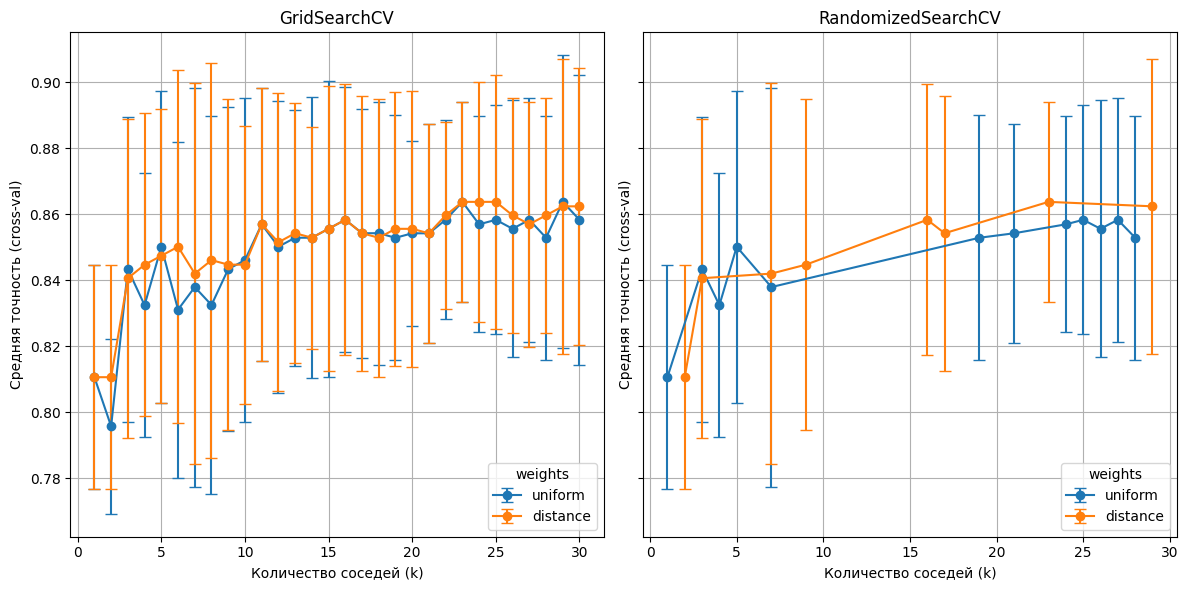


Лучшие результаты

GridSearchCV — лучшее Accuracy: 0.8638 при лучших параметрах {'classifier__n_neighbors': 29, 'classifier__weights': 'uniform'}, время: 3.86 с
RandomizedSearchCV — лучшее Accuracy: 0.8638 при лучших параметрах {'classifier__weights': 'distance', 'classifier__n_neighbors': 23}, время: 1.31 с


In [ ]:
# визуализация и сравнение результатов работы GridSearchCV и RandomizedSearchCV
# результаты GridSearchCV
grid_results_df = pd.DataFrame(grid_cv_results)

# результаты RandomizedSearchCV
rand_results_df = pd.DataFrame(rand_cv_results)

# графики
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# GridSearchCV
for weight in param_grid['classifier__weights']:
    subset = grid_results_df[
        grid_results_df['param_classifier__weights'] == weight
        ].sort_values('param_classifier__n_neighbors')

    axes[0].errorbar(
        subset['param_classifier__n_neighbors'],
        subset['mean_test_score'],
        yerr=subset['std_test_score'],
        fmt='-o',
        label=weight,
        capsize=4
        )

# RandomizedSearchCV
for weight in param_grid['classifier__weights']:
    subset = rand_results_df[
        rand_results_df['param_classifier__weights'] == weight
        ].sort_values('param_classifier__n_neighbors')

    axes[1].errorbar(
        subset['param_classifier__n_neighbors'],
        subset['mean_test_score'],
        yerr=subset['std_test_score'],
        fmt='-o',
        label=weight,
        capsize=4
        )

for ax in axes:
    ax.set_xlabel('Количество соседей (k)')
    ax.set_ylabel('Средняя точность (cross-val)')
    ax.grid(True)
    ax.legend(title='weights')

axes[0].set_title('GridSearchCV')
axes[1].set_title('RandomizedSearchCV')

plt.tight_layout()
plt.show()

print('\nЛучшие результаты\n')
print(f'GridSearchCV — лучшее Accuracy: {grid_best_score:.4f} при лучших параметрах {grid_best_params}, время: {grid_time:.2f} с')
print(f'RandomizedSearchCV — лучшее Accuracy: {rand_best_score:.4f} при лучших параметрах {rand_best_params}, время: {rand_time:.2f} с')

Оптимальные настройки `GridSearchCV` и `RandomizedSearchCV` отличаются:
* у `GridSearchCV`: `n_neighbors=29`, `weights='uniform'`
* у `RandomizedSearchCV`: `n_neighbors=23`, `weights='distance`'

При этом качество оказалось абсолютно одинаковым: у обоих методов лучшее `Accuracy = 0.8638`, то есть разницы в качестве нет.

По времени `RandomizedSearchCV` значительно, почти в 5 раз, быстрее: примерно 1.33 с против 6.56 с у `GridSearchCV`. Это объясняется тем, что случайный поиск проверяет только часть комбинаций, тогда как `GridSearchCV` перебирает всю сетку.

Можно уверенно утверждать, что в данной задаче `RandomizedSearchCV` оказался более эффективным по времени без потери качества.

### 6. Сравнение с другой моделью.

* Обучите дополнительную модель на тех же данных.
* Оцените качество этой модели с помощью cross_val_score, используя тот же способ кросс‑валидации и тот же тип метрики, что и для KNN.
* Сравните среднюю метрику и разброс метрики по фолдам.
* Сделайте вывод: какая модель выглядит предпочтительнее для данной задачи и почему (качество, устойчивость, интерпретируемость).

In [ ]:
# создание пайплайна предобработки и обучения модели SVM
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True))
    ])

In [ ]:
# обучение базовой модели модели
svm_pipeline.fit(X_train, y_train)

# предсказания
y_pred_svm = svm_pipeline.predict(X_test)
y_pred_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

# расчет и вывод метрик базовой модели
svm_baseline_metrics_df = pd.DataFrame({
    'Metrics': ['Accuracy', 'F1', 'ROC-AUC'],
    'SVM_baseline': [
        accuracy_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
        roc_auc_score(y_test, y_pred_proba_svm)
        ]
    })

print('Метрики базового SVM:\n')
svm_baseline_metrics_df.round(4)

Метрики базового SVM:



,Metrics,SVM_baseline
0,Accuracy,0.8967
1,F1,0.9100
2,ROC-AUC,0.9460


In [ ]:
# реализация cross_val_score для SVM
cv_scores_svm = cross_val_score(svm_pipeline, X_train, y_train, cv=5)

print(f'Оценки по фолдам: {cv_scores_svm}')
print(f'Средняя точность: {cv_scores_svm.mean():.3f}')
print(f'Стандартное отклонение: {cv_scores_svm.std():.3f}')

Оценки по фолдам: [0.89115646 0.87755102 0.89115646 0.85034014 0.81506849]
Средняя точность: 0.865
Стандартное отклонение: 0.029


In [ ]:
# cводная таблица по Accuracy для SVM
svm_cv_summary_df = pd.DataFrame({
    'Metrics': ['Test Accuracy', 'CV Mean Accuracy', 'CV Std'],
    'SVM': [
        svm_baseline_metrics_df.loc[
            svm_baseline_metrics_df['Metrics'] == 'Accuracy',
            'SVM_baseline'
        ].iloc[0],
        cv_scores_svm.mean(),
        cv_scores_svm.std()
        ]
    })

print('Сводная таблица по Accuracy для SVM\n')
svm_cv_summary_df.round(4)

Сводная таблица по Accuracy для SVM



,Metrics,SVM
0,Test Accuracy,0.8967
1,CV Mean Accuracy,0.8651
2,CV Std,0.0291


In [ ]:
# сравнение KNN и SVM
comparison_df = knn_cv_summary_df.merge(svm_cv_summary_df, on='Metrics')
comparison_df

,Metrics,KNN,SVM
0,Test Accuracy,0.891304,0.896739
1,CV Mean Accuracy,0.843295,0.865055
2,CV Std,0.015836,0.029099


`SVM` показал более высокое качество: средняя `Accuracy` по кросс-валидации `0.8651` против `0.8433` у `KNN`. При этом `KNN` немного устойчивее, так как его стандартное отклонение ниже (`0.0158` против `0.0291`). Обе модели не слишком интерпретируемы, `KNN` наверно чуть проще объяснить на интуитивном уровне.

 Для данной задачи предпочтительнее `SVM`, потому что прирост в среднем качестве заметнее, чем небольшая потеря в устойчивости.

### 7. Реализация Байесовской оптимизации.

Воспользуйтесь библиотекой `hyperopt` для оптимизации гиперпараметров `KNN`.

* Задайте пространство гиперпараметров с помощью модуля `hp`.
* Определите целевую функцию:
    * функция принимает словарь гиперпараметров;
    * внутри создаёт модель `KNN` с этими параметрами;
    * считает `cross_val_score` с `scoring=“accuracy”`;
    * возвращает отрицательное среднее значение метрики.
* Создайте объект `Trials` для сохранения истории поиска.
* Вызовите `fmin`, указав:
    * целевую функцию;
    * пространство поиска;
    * алгоритм `tpe.suggest`;
    * максимальное количество оценок (`max_evals`).
* Сравните результат Байесовской оптимизации с `GridSearchCV` и `RandomizedSearchCV`:
    * какое качество удалось получить;
    * сколько итераций потребовалось;
    * совпадает ли найденный оптимум;
    * в чём преимущество вероятностного подхода (`TPE`) по сравнению с полным перебором и случайным поиском.

In [ ]:
# пространство гиперпараметров
search_space = {
    'n_neighbors': hp.choice('n_neighbors', options=list(range(1, 31))),
    'weights': hp.choice('weights', options=['uniform', 'distance'])
    }

# целевая функция
def knn_objective(params):
    """Оценивает качество KNN с заданными гиперпараметрами.
    Создаёт копию пайплайна KNN, устанавливает переданные
    гиперпараметры и оценивает модель с помощью кросс-валидации.
    Args:
        params (dict): Словарь гиперпараметров KNN.
    Returns:
        float: Отрицательное среднее значение Accuracy
        по результатам кросс-валидации.
    """
    knn = clone(knn_pipeline)

    knn.set_params(
        classifier__n_neighbors=params['n_neighbors'],
        classifier__weights=params['weights']
        )

    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
        )

    return -scores.mean()

In [ ]:
# объект для испытаний
tpe_algorithm = tpe.suggest

# объект Trials для сохранения истории поиска
tpe_trials = Trials()

In [ ]:
# прогон 30 оценок по алгоритму TPE
tpe_best = fmin(
    fn=knn_objective,
    space=search_space,
    algo=tpe_algorithm,
    trials=tpe_trials,
    max_evals=30,
    rstate=np.random.default_rng(42)
    )

100%|██████████| 30/30 [00:03<00:00,  9.34trial/s, best loss: -0.863768521107073]


In [ ]:
# получение подобранных лучших значений гиперпараметров
tpe_best_params = space_eval(search_space, tpe_best)

# значения loss на итерациях
tpe_losses = [trial['result']['loss'] for trial in tpe_trials.trials]

# лучшее Accuracy
tpe_best_score = -min(tpe_losses)

# итерация с первым лучшим результатом
tpe_best_iter = np.argmin(tpe_losses) + 1

print(f'Лучшие параметры TPE:\n {tpe_best_params}')
print(f'Лучшее Accuracy:\n {tpe_best_score:.4f}')
print(f'Лучший результат найден на итерации:\n {tpe_best_iter}')
print(f'Всего итераций выполнено:\n {len(tpe_trials.trials)}')

Лучшие параметры TPE:
 {'n_neighbors': 23, 'weights': 'distance'}
Лучшее Accuracy:
 0.8638
Лучший результат найден на итерации:
 6
Всего итераций выполнено:
 30


In [ ]:
# таблица сравнения методом оптимизации
optimization_comparison_df = pd.DataFrame({
    'Method': [
        'GridSearchCV',
        'RandomizedSearchCV',
        'TPE'
    ],
    'Best Accuracy': [
        grid_best_score,
        rand_best_score,
        tpe_best_score
    ],
    'Best Parameters': [
        grid_best_params,
        rand_best_params,
        tpe_best_params
    ],
    'Evaluations': [
        60,
        20,
        len(tpe_trials.trials)
    ]
})

pd.set_option('display.max_colwidth', None)
print('Таблица сравнения методом оптимизации\n')
optimization_comparison_df

Таблица сравнения методом оптимизации



,Method,Best Accuracy,Best Parameters,Evaluations
0,GridSearchCV,0.863778,"{'classifier__n_neighbors': 29, 'classifier__weights': 'uniform'}",60
1,RandomizedSearchCV,0.863769,"{'classifier__weights': 'distance', 'classifier__n_neighbors': 23}",20
2,TPE,0.863769,"{'n_neighbors': 23, 'weights': 'distance'}",30


`GridSearchCV` показал немного лучшую среднюю `Accuracy` по кросс-валидации (`0.863778`), выбрав `n_neighbors=29` и `weights='uniform'`. `RandomizedSearchCV` и `TPE` получили практически такое же качество (`0.863769`) и выбрали одинаковые параметры: `n_neighbors=23`, `weights='distance'`.

При этом `GridSearchCV` потребовал 60 оценок, `RandomizedSearchCV` — 20, а TPE — 30. Поэтому в данном небольшом пространстве параметров наиболее эффективным оказался `RandomizedSearchCV`: он нашёл практически такое же решение за наименьшее число оценок. Преимущество `TPE` здесь не проявилось, однако на более сложных и больших пространствах его адаптивный поиск может быть полезнее.

### 8. Выводы по работе.

* Сравните все рассмотренные модели и настройки (базовый KNN, KNN после тюнинга разными методами, альтернативная модель).
* Обсудите, как предобработка данных (кодирование, масштабирование, балансировка) повлияла на качество.
* Укажите, какую модель вы выбрали бы для практического использования и почему (включая метрику и устойчивость качества).
* Кратко свяжите выбор гиперпараметров с переобучением/недообучением (например, малый k в KNN → склонность к переобучению).

In [ ]:
# общая финальная таблица сравнения моделей и методов настройки
final_comparison_df = pd.DataFrame({
    'Method': [
        'KNN baseline',
        'KNN GridSearchCV',
        'KNN RandomizedSearchCV',
        'KNN TPE',
        'SVM baseline'
    ],
    'CV Mean Accuracy': [
        cv_scores.mean(),
        grid_best_score,
        rand_best_score,
        tpe_best_score,
        cv_scores_svm.mean()
    ],
    'CV Std': [
        cv_scores.std(),
        np.nan,
        np.nan,
        np.nan,
        cv_scores_svm.std()
    ],
    'Test Accuracy': [
        knn_baseline_metrics_df.loc[
            knn_baseline_metrics_df['Metrics'] == 'Accuracy',
            'KNN_baseline'
        ].iloc[0],
        np.nan,
        np.nan,
        np.nan,
        svm_baseline_metrics_df.loc[
            svm_baseline_metrics_df['Metrics'] == 'Accuracy',
            'SVM_baseline'
        ].iloc[0]
    ],
    'Best Parameters': [
        'default',
        grid_best_params,
        rand_best_params,
        tpe_best_params,
        'default'
    ],
    'Evaluations': [
        np.nan,
        60,
        20,
        len(tpe_trials.trials),
        np.nan
    ]
})

pd.set_option('display.max_colwidth', None)

print('Финальная таблица сравнения моделей и методов\n')
display(final_comparison_df.round(4))

Финальная таблица сравнения моделей и методов



,Method,CV Mean Accuracy,CV Std,Test Accuracy,Best Parameters,Evaluations
0,KNN baseline,0.8433,0.0158,0.8913,default,NaN
1,KNN GridSearchCV,0.8638,NaN,NaN,"{'classifier__n_neighbors': 29, 'classifier__weights': 'uniform'}",60.0
2,KNN RandomizedSearchCV,0.8638,NaN,NaN,"{'classifier__weights': 'distance', 'classifier__n_neighbors': 23}",20.0
3,KNN TPE,0.8638,NaN,NaN,"{'n_neighbors': 23, 'weights': 'distance'}",30.0
4,SVM baseline,0.8651,0.0291,0.8967,default,NaN


In [ ]:
# сравнение всех моделей на тестовой выборке
# лучшие модели GridSearchCV и RandomizedSearchCV
knn_grid_best = grid_search.best_estimator_
knn_rand_best = rand_search.best_estimator_

# лучшая модель TPE
knn_tpe_best = clone(knn_pipeline)

knn_tpe_best.set_params(
    classifier__n_neighbors=tpe_best_params['n_neighbors'],
    classifier__weights=tpe_best_params['weights']
)

knn_tpe_best.fit(X_train, y_train)

# настроенные модели KNN
tuned_knn_models = {
    'KNN GridSearchCV': knn_grid_best,
    'KNN RandomizedSearchCV': knn_rand_best,
    'KNN TPE': knn_tpe_best
}

tuned_knn_results = []

for name, model in tuned_knn_models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    tuned_knn_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    })

# итоговое сравнение всех моделей на тестовой выборке
final_test_comparison_df = pd.DataFrame([
    {
        'Model': 'KNN baseline',
        'Accuracy': accuracy_score(y_test, y_pred_knn),
        'F1': f1_score(y_test, y_pred_knn),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_knn)
    },
    *tuned_knn_results,
    {
        'Model': 'SVM baseline',
        'Accuracy': accuracy_score(y_test, y_pred_svm),
        'F1': f1_score(y_test, y_pred_svm),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_svm)
    }
])

print('Сравнение моделей на тестовой выборке\n')
display(final_test_comparison_df.round(4))

Сравнение моделей на тестовой выборке



,Model,Accuracy,F1,ROC-AUC
0,KNN baseline,0.8913,0.9020,0.9366
1,KNN GridSearchCV,0.9130,0.9216,0.9452
2,KNN RandomizedSearchCV,0.9239,0.9320,0.9448
3,KNN TPE,0.9239,0.9320,0.9448
4,SVM baseline,0.8967,0.9100,0.9460


Базовый `KNN` показал `Test Accuracy = 0.8913`. Настройка гиперпараметров улучшила его качество: `GridSearchCV` достиг `Test Accuracy = 0.9130`, а `RandomizedSearchCV` и `TPE` — `0.9239`. Таким образом, подбор гиперпараметров заметно улучшил качество `KNN` на тестовой выборке.

Лучшие результаты по `Accuracy` и `F1` показали `KNN`, настроенные с помощью `RandomizedSearchCV` и `TPE` (`Accuracy = 0.9239`, `F1 = 0.9320`). `SVM` показал несколько меньшую Accuracy (`0.8967`), но максимальный `ROC-AUC = 0.9460`; у настроенных `KNN` `ROC-AU`C также находится на близком уровне (`≈0.945`).

Предобработка данных была особенно важна для `KNN` и `SVM`: категориальные признаки были закодированы, а непрерывные числовые признаки масштабированы внутри `Pipeline`, что предотвращает утечку данных при кросс-валидации.

Для данной задачи наиболее практичным вариантом можно считать `KNN` с `n_neighbors=23` и `weights='distance'`: он показал лучшее качество на тестовой выборке, а `RandomizedSearchCV` нашёл эти параметры всего за 20 оценок. При этом различия между методами оптимизации невелики, поэтому результаты следует рассматривать с учётом ограниченного размера тестовой выборки.

Для `KNN` выбор `k` (количество соседей) напрямую связан с переобучением и недообучением: слишком малое `k` повышает чувствительность к шуму и риск переобучения, а слишком большое `k` чрезмерно сглаживает границу классов и может привести к недообучению. Параметр `weights` (тип весов) тоже влияет на гибкость модели: `distance` сильнее учитывает ближайшие объекты и может сделать модель более чувствительной к локальным особенностям данных, тогда как `uniform` действует более сглаженно. Поэтому сочетание `k` и `weights` важно подбирать совместно по кросс-валидации.